<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN-nhandienlongbantay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [4]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.3 MB/s eta 0:00:00


In [9]:
from google.colab import files
import zipfile

uploaded = files.upload()

# Giải nén thư mục
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content/palm2_data")

Saving bàn tay.zip to bàn tay.zip


In [11]:
zip_path = "/content/bàn tay.zip"
extract_path = "/content/longbantay_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [12]:
classes = sorted(os.listdir("/content/longbantay_data/bàn tay"))

img_size = (100, 100)
X = []
y = []

#load ảnh vào
for i, label in enumerate(classes):
    folder = os.path.join("/content/longbantay_data/bàn tay", label)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(i)
        except:
            print("")

X = np.array(X)
y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình ANN
model = Sequential([
    Flatten(input_shape=img_size + (3,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,848,579 (14.68 MB)

 Trainable params: 3,848,579 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.4050 - loss: 6.2485 - val_accuracy: 0.2903 - val_loss: 17.0267
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.3854 - loss: 9.9081 - val_accuracy: 0.7097 - val_loss: 2.7494
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5587 - loss: 2.8411 - val_accuracy: 0.5161 - val_loss: 1.5159
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.6040 - loss: 1.2184 - val_accuracy: 1.0000 - val_loss: 0.2126
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.8471 - loss: 0.3362 - val_accuracy: 1.0000 - val_loss: 0.1554
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8804 - loss: 0.2162 - val_accuracy: 1.0000 - val_loss: 0.0664
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 1.0000 - loss: 0.0766 - val_accuracy: 1.0000 - val_loss: 0.0917
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 1.0000 - loss: 0.0708 - val_accuracy: 1.0000 - val_loss

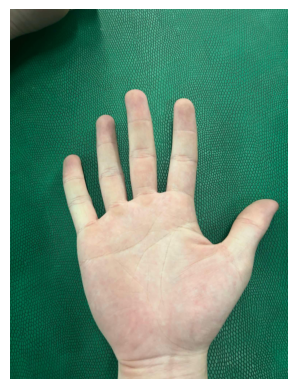

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
 người dự đoán: **Quân**
 Xác suất: 95.26%


In [17]:
def predict_image(img_path):
    img_display = load_img(img_path)
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

    img = load_img(img_path, target_size=(100, 100))
    img = img_to_array(img) / 255.0 #chuẩn hóa 0-1
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)
    confidence = np.max(pred)

    print(f" người dự đoán: **{classes[class_index]}**")
    print(f" Xác suất: {confidence * 100:.2f}%")

predict_image("/content/ddb9b712-487e-47f7-8292-ed1e9d20c750.jpg")
